In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('dataset.csv')


In [4]:
df.columns

Index(['Test Sample', 'Experimental Run', 'Infill Density (%)',
       'Nozzle Temperature (C)', 'Infill Pattern', 'Mean Tensile Stress (MPa)',
       'Tensile Stress SD (MPa)'],
      dtype='object')

# Gausian Noise

In [5]:
import pandas as pd
import numpy as np

def augment_data_vectorized(df, n_synthetic=10):
    """
    Expands the dataset by generating synthetic samples using Gaussian noise.
    
    Args:
        df: The original DataFrame.
        n_synthetic: Number of synthetic points to generate per original row.
    """
    # 1. Repeat each row n_synthetic times
    df_aug = df.loc[df.index.repeat(n_synthetic)].reset_index(drop=True)
    
    # 2. Generate Gaussian noise: Mean = 0, SD = 1
    # We multiply this by the actual SD from the table to scale the noise
    noise = np.random.normal(size=len(df_aug))
    
    # 3. Apply the noise: New Value = Mean + (Noise * SD)
    df_aug['Tensile Stress (Augmented)'] = (
        df_aug['Mean Tensile Stress (MPa)'] + 
        (noise * df_aug['Tensile Stress SD (MPa)'])
    ).round(3)
    
    # 4. Shuffle the dataset so the model doesn't learn the order of experiments
    return df_aug.sample(frac=1).reset_index(drop=True)

# Execute the augmentation
# If you have 33 rows, this will result in 330 rows
augmented_df = augment_data_vectorized(df, n_synthetic=3)

# Display a preview
print(f"Dataset expanded from {len(df)} to {len(augmented_df)} rows.")
print(augmented_df[['Infill Pattern', 'Mean Tensile Stress (MPa)', 'Tensile Stress (Augmented)']].head())

Dataset expanded from 33 to 99 rows.
  Infill Pattern  Mean Tensile Stress (MPa)  Tensile Stress (Augmented)
0           Grid                      13.67                      13.321
1  Triangle-Hexa                      10.70                      11.996
2  Triangle-Hexa                      16.94                      17.195
3  Triangle-Hexa                      11.08                      10.695
4           Grid                      14.26                      15.028


In [6]:
augmented_df.columns

Index(['Test Sample', 'Experimental Run', 'Infill Density (%)',
       'Nozzle Temperature (C)', 'Infill Pattern', 'Mean Tensile Stress (MPa)',
       'Tensile Stress SD (MPa)', 'Tensile Stress (Augmented)'],
      dtype='object')

In [7]:
augmented_df

,Test Sample,Experimental Run,Infill Density (%),Nozzle Temperature (C),Infill Pattern,Mean Tensile Stress (MPa),Tensile Stress SD (MPa),Tensile Stress (Augmented)
0,2,4,74.14,225.86,Grid,13.67,0.54,13.321
1,27,8,40.00,240.00,Triangle-Hexa,10.70,0.38,11.996
2,26,11,74.14,254.14,Triangle-Hexa,16.94,0.61,17.195
3,23,5,45.87,225.86,Triangle-Hexa,11.08,0.29,10.695
4,10,31,60.00,240.00,Grid,14.26,0.51,15.028
...,...,...,...,...,...,...,...,...
94,32,15,60.00,240.00,Triangle-Hexa,14.51,0.57,14.939
95,8,32,60.00,260.00,Grid,17.76,0.75,17.118
96,15,9,74.14,254.14,Triangle,17.71,0.58,18.681
97,27,8,40.00,240.00,Triangle-Hexa,10.70,0.38,10.662


In [8]:
# one-hot encode the 'Infill Pattern' column
df_encoded = pd.get_dummies(augmented_df, columns=['Infill Pattern'])
df_encoded['Infill Pattern_Grid'] = df_encoded['Infill Pattern_Grid'].astype(int)
df_encoded['Infill Pattern_Triangle'] = df_encoded['Infill Pattern_Triangle'].astype(int)
df_encoded['Infill Pattern_Triangle-Hexa'] = df_encoded['Infill Pattern_Triangle-Hexa'].astype(int)



In [9]:
print (df_encoded.describe())

       Test Sample  Experimental Run  Infill Density (%)  \
count    99.000000         99.000000           99.000000   
mean     17.000000         17.000000           60.000606   
std       9.570362          9.570362           12.120201   
min       1.000000          1.000000           40.000000   
25%       9.000000          9.000000           45.870000   
50%      17.000000         17.000000           60.000000   
75%      25.000000         25.000000           74.140000   
max      33.000000         33.000000           80.000000   

       Nozzle Temperature (C)  Mean Tensile Stress (MPa)  \
count               99.000000                  99.000000   
mean               240.000000                  13.461818   
std                 12.120915                   2.702307   
min                220.000000                   8.420000   
25%                225.860000                  11.080000   
50%                240.000000                  13.670000   
75%                254.140000          

# baseline corrilation

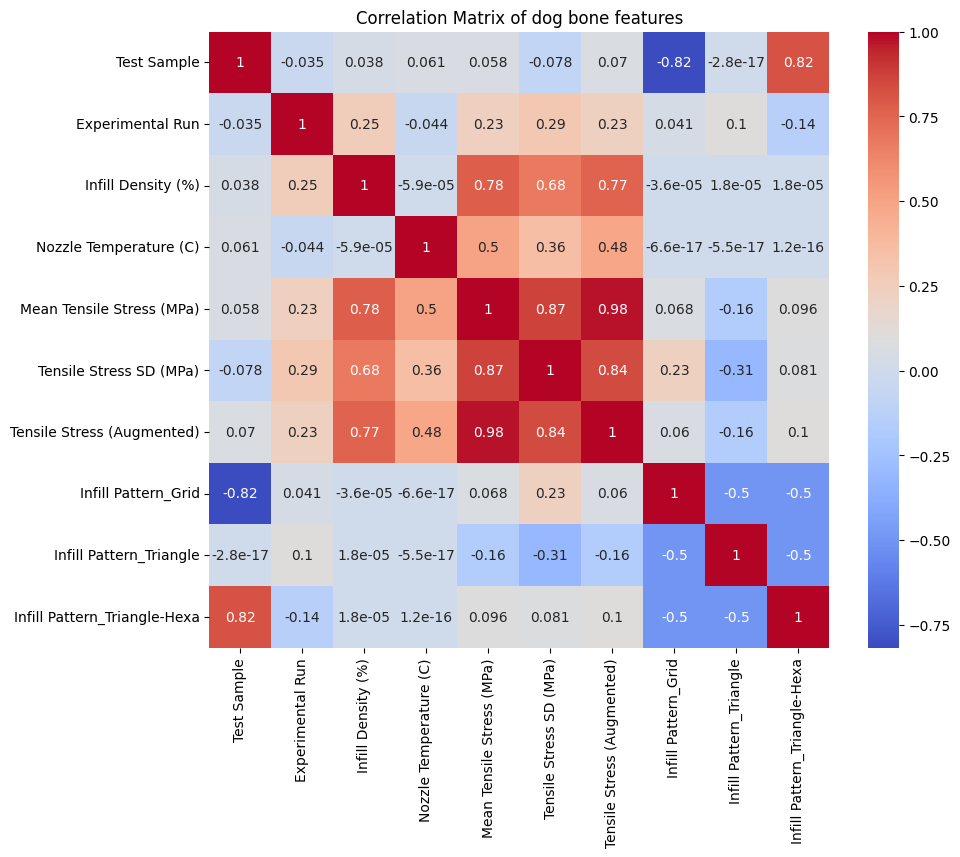

In [10]:
from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of dog bone features')
plt.show()

In [11]:
df_encoded.columns

Index(['Test Sample', 'Experimental Run', 'Infill Density (%)',
       'Nozzle Temperature (C)', 'Mean Tensile Stress (MPa)',
       'Tensile Stress SD (MPa)', 'Tensile Stress (Augmented)',
       'Infill Pattern_Grid', 'Infill Pattern_Triangle',
       'Infill Pattern_Triangle-Hexa'],
      dtype='object')

## Effective Area ($A_{eff}$)

In [12]:
# Create a mapping for the Geometry Factor
# Note: Since your data is one-hot encoded, we multiply by the column indicator
df_encoded['Effective Load-Bearing Area (Aeff)'] = df_encoded['Infill Density (%)'] * (
    (df_encoded['Infill Pattern_Triangle-Hexa'] * 1.0) +
    (df_encoded['Infill Pattern_Triangle'] * 0.85) +
    (df_encoded['Infill Pattern_Grid'] * 0.70)
)

In [13]:
df_encoded

,Test Sample,Experimental Run,Infill Density (%),Nozzle Temperature (C),Mean Tensile Stress (MPa),Tensile Stress SD (MPa),Tensile Stress (Augmented),Infill Pattern_Grid,Infill Pattern_Triangle,Infill Pattern_Triangle-Hexa,Effective Load-Bearing Area (Aeff)
0,2,4,74.14,225.86,13.67,0.54,13.321,1,0,0,51.898
1,27,8,40.00,240.00,10.70,0.38,11.996,0,0,1,40.000
2,26,11,74.14,254.14,16.94,0.61,17.195,0,0,1,74.140
3,23,5,45.87,225.86,11.08,0.29,10.695,0,0,1,45.870
4,10,31,60.00,240.00,14.26,0.51,15.028,1,0,0,42.000
...,...,...,...,...,...,...,...,...,...,...,...
94,32,15,60.00,240.00,14.51,0.57,14.939,0,0,1,60.000
95,8,32,60.00,260.00,17.76,0.75,17.118,1,0,0,42.000
96,15,9,74.14,254.14,17.71,0.58,18.681,0,1,0,63.019
97,27,8,40.00,240.00,10.70,0.38,10.662,0,0,1,40.000


## polymer difusin rate

In [14]:
# 1. Define Constants
Ea = 68000  # Activation Energy for PA6 (J/mol)
R = 8.314    # Gas Constant
T_kelvin = df_encoded['Nozzle Temperature (C)'] + 273.15

# 2. Calculate Polymer Diffusion Rate
# We can set D0 = 1 for relative comparison
df_encoded['Diffusion Rate'] = np.exp(-Ea / (R * T_kelvin))

# 3. Normalize it so it stays on a 0-1 scale like your other features
df_encoded['Diffusion_Rate_Normalized'] = (df_encoded['Diffusion Rate'] - df_encoded['Diffusion Rate'].min()) / \
                                          (df_encoded['Diffusion Rate'].max() - df_encoded['Diffusion Rate'].min())

In [15]:
df_encoded[['Mean Tensile Stress (MPa)','Tensile Stress SD (MPa)', 'Tensile Stress (Augmented)']]

,Mean Tensile Stress (MPa),Tensile Stress SD (MPa),Tensile Stress (Augmented)
0,13.67,0.54,13.321
1,10.70,0.38,11.996
2,16.94,0.61,17.195
3,11.08,0.29,10.695
4,14.26,0.51,15.028
...,...,...,...
94,14.51,0.57,14.939
95,17.76,0.75,17.118
96,17.71,0.58,18.681
97,10.70,0.38,10.662


# physics augmented corrilation

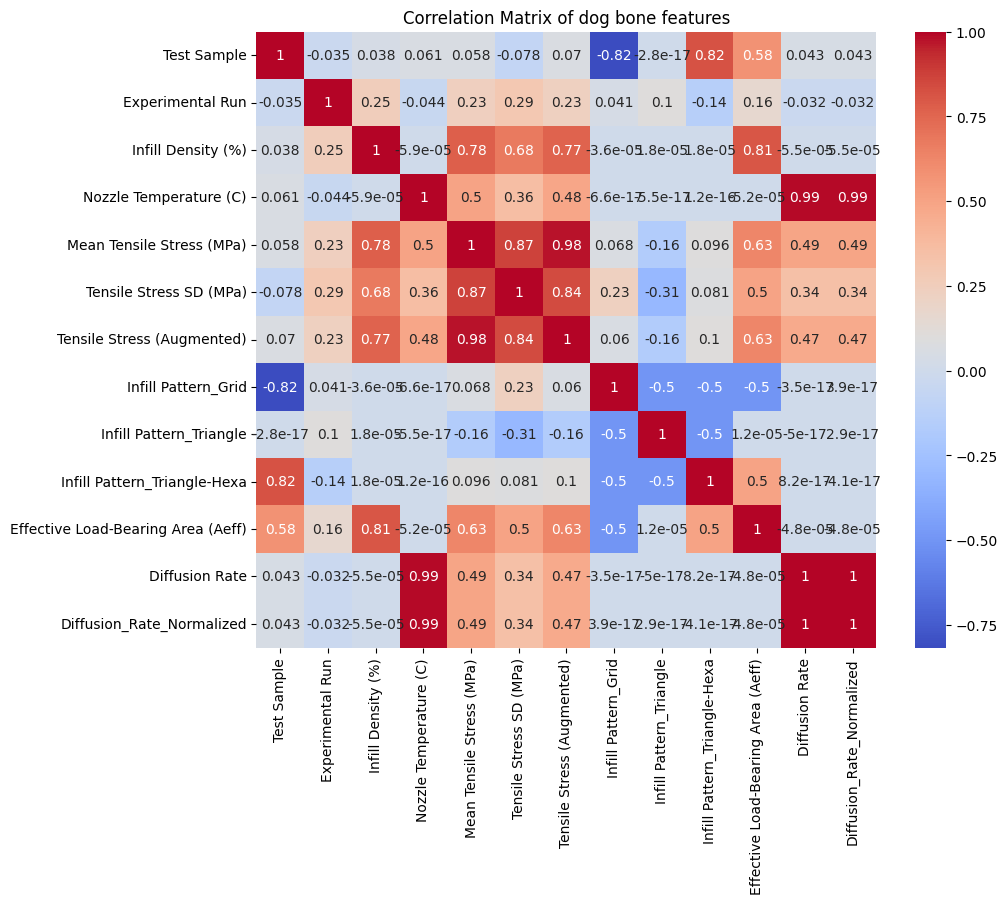

In [16]:
from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of dog bone features')
plt.show()

In [17]:
df_encoded

,Test Sample,Experimental Run,Infill Density (%),Nozzle Temperature (C),Mean Tensile Stress (MPa),Tensile Stress SD (MPa),Tensile Stress (Augmented),Infill Pattern_Grid,Infill Pattern_Triangle,Infill Pattern_Triangle-Hexa,Effective Load-Bearing Area (Aeff),Diffusion Rate,Diffusion_Rate_Normalized
0,2,4,74.14,225.86,13.67,0.54,13.321,1,0,0,51.898,7.616198e-08,0.087035
1,27,8,40.00,240.00,10.70,0.38,11.996,0,0,1,40.000,1.196421e-07,0.367799
2,26,11,74.14,254.14,16.94,0.61,17.195,0,0,1,74.140,1.834467e-07,0.779806
3,23,5,45.87,225.86,11.08,0.29,10.695,0,0,1,45.870,7.616198e-08,0.087035
4,10,31,60.00,240.00,14.26,0.51,15.028,1,0,0,42.000,1.196421e-07,0.367799
...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,32,15,60.00,240.00,14.51,0.57,14.939,0,0,1,60.000,1.196421e-07,0.367799
95,8,32,60.00,260.00,17.76,0.75,17.118,1,0,0,42.000,2.175468e-07,1.000000
96,15,9,74.14,254.14,17.71,0.58,18.681,0,1,0,63.019,1.834467e-07,0.779806
97,27,8,40.00,240.00,10.70,0.38,10.662,0,0,1,40.000,1.196421e-07,0.367799


# Features defination

In [18]:
# Physics-Augmented Features

FEATURES_PHYSICS = [
    # 'Test Sample', 
    # 'Experimental Run', 
    'Infill Density (%)', 
    'Infill Pattern_Grid', 
    'Infill Pattern_Triangle', 
    'Infill Pattern_Triangle-Hexa', 
    'Effective Load-Bearing Area (Aeff)', 
    'Diffusion_Rate_Normalized'
]


# Baseline Features (Standard Engineering)
FEATURES_BASE = [
    # 'Test Sample', 
    # 'Experimental Run', 
    'Infill Density (%)', 
    'Nozzle Temperature (C)', 
    'Infill Pattern_Grid', 
    'Infill Pattern_Triangle', 
    'Infill Pattern_Triangle-Hexa'
]

# Defining the target
target_augmented = 'Tensile Stress (Augmented)'
target_validation = 'Mean Tensile Stress (MPa)'

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_base = df_encoded[FEATURES_BASE]
y = df_encoded[target_augmented]

# base features
X_train_base, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_base.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 5)
Shape of X_test: (20, 5)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [20]:
y_test.describe()

count    20.000000
mean     14.168300
std       2.147836
min      10.578000
25%      12.879000
50%      14.505000
75%      15.058250
max      17.582000
Name: Tensile Stress (Augmented), dtype: float64

# RF baseline

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf_base = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train_base, y_train)

y_pred = rf_base.predict(X_test)

rf_r2_base  = r2_score(y_test, y_pred)
rf_mse_base = mean_squared_error(y_test, y_pred)
rf_rmse_base = np.sqrt(rf_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()
rf_acc_2_5_base = tolerance_accuracy(y_test.values, y_pred, 0.25)
rf_acc_05_base = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10_base = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20_base = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30_base = tolerance_accuracy(y_test.values, y_pred, 3.0)
print(f"=== Random Forest Prediction (Test) for BaseLine Features ===")
print(f"R²          : {rf_r2_base:.4f}")
print(f"RMSE        : {rf_rmse_base:.3f} MPa")
print(f"MSE         : {rf_mse_base:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {rf_acc_2_5_base* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {rf_acc_05_base * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {rf_acc_10_base * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {rf_acc_20_base * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
rf_cv_r2_base = cross_val_score(rf_base, X_base, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for BaseLine Features ===")
print(f"Mean R² : {rf_cv_r2_base.mean():.4f}  (±{rf_cv_r2_base.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2_base, 4)}")

rf_cv_r2_base = rf_cv_r2_base.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': rf_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest Prediction (Test) for BaseLine Features ===
R²          : 0.8895
RMSE        : 0.830 MPa
MSE         : 0.6883 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 35.00%
  Engineering    (±0.50 MPa): 45.00%
  Acceptable     (±1.00 MPa): 75.00%
  Upper Bound    (±2.00 MPa): 100.00%

=== KFolf CV Evaluation Marix for BaseLine Features ===
Mean R² : 0.8404  (±0.0608)
Scores  : [0.894  0.8177 0.7476 0.8235 0.9193]

=== Feature Importances (Top 10) ===
                     feature  importance
          Infill Density (%)    0.612641
      Nozzle Temperature (C)    0.294378
     Infill Pattern_Triangle    0.038385
Infill Pattern_Triangle-Hexa    0.029685
         Infill Pattern_Grid    0.024912


# rf physics

In [88]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_physics = df_encoded[FEATURES_PHYSICS]
y = df_encoded[target_augmented]

# physics features
X_train_physics, X_test, y_train, y_test = train_test_split(X_physics, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_physics.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 6)
Shape of X_test: (20, 6)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf_physics = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
rf_physics.fit(X_train_physics, y_train)

y_pred = rf_physics.predict(X_test)

rf_r2_physics  = r2_score(y_test, y_pred)
rf_mse_physics = mean_squared_error(y_test, y_pred)
rf_rmse_physics = np.sqrt(rf_mse_physics)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()
rf_acc_2_5_physics = tolerance_accuracy(y_test.values, y_pred, 0.25)
rf_acc_05_physics = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10_physics = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20_physics = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30_physics = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== Random Forest Prediction (Test) for Physics Augmented Features ===")
print(f"R²          : {rf_r2_physics:.4f}")
print(f"RMSE        : {rf_rmse_physics:.3f} MPa")
print(f"MSE         : {rf_mse_physics:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): { rf_acc_2_5_physics* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {rf_acc_05_physics * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {rf_acc_10_physics * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {rf_acc_20_physics * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
rf_cv_r2_physics = cross_val_score(rf_physics, X_physics, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Physics Augmented Features ===")
print(f"Mean R² : {rf_cv_r2_physics.mean():.4f}  (±{rf_cv_r2_physics.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2_physics, 4)}")

rf_cv_r2_physics = rf_cv_r2_physics.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_PHYSICS,
    'importance': rf_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== Random Forest Prediction (Test) for Physics Augmented Features ===
R²          : 0.8804
RMSE        : 0.863 MPa
MSE         : 0.7449 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 25.00%
  Engineering    (±0.50 MPa): 45.00%
  Acceptable     (±1.00 MPa): 85.00%
  Upper Bound    (±2.00 MPa): 95.00%

=== KFolf CV Evaluation Marix for Physics Augmented Features ===
Mean R² : 0.8381  (±0.0633)
Scores  : [0.8813 0.7931 0.8043 0.7713 0.9406]

=== Feature Importances (Top 10) ===
                           feature  importance
Effective Load-Bearing Area (Aeff)    0.339758
                Infill Density (%)    0.330966
         Diffusion_Rate_Normalized    0.253088
           Infill Pattern_Triangle    0.029241
               Infill Pattern_Grid    0.023599
      Infill Pattern_Triangle-Hexa    0.023349


In [90]:
rf_cv_r2_physics

np.float64(0.8381284513988175)

In [91]:
print("======== Random Forest =============\n")
print("comparision between baseline and physics augmented predictions\n")
print(f"Baseline R²: {rf_r2_base:.4f}   | Physics-Augmented R²: {rf_r2_physics:.4f}")
print(f"Baseline CV R²: {rf_cv_r2_base:.4f}| Physics-Augmented CV R²: {rf_cv_r2_physics:.4f}")
print(f"Baseline mse: {rf_mse_base: .4f} | Physics-Augmented mse: {rf_mse_physics:.4f}")
print(f"Baseline rmse: {rf_rmse_base: .4f}| Physics-Augmented rmse: {rf_rmse_physics:.4f}")

======== Random Forest =============

comparision between baseline and physics augmented predictions

Baseline R²: 0.8895   | Physics-Augmented R²: 0.8804
Baseline CV R²: 0.8404| Physics-Augmented CV R²: 0.8381
Baseline mse:  0.6883 | Physics-Augmented mse: 0.7449
Baseline rmse:  0.8296| Physics-Augmented rmse: 0.8631


# XGBoost baseline


In [92]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_base = df_encoded[FEATURES_BASE]
y = df_encoded[target_augmented]

# base features
X_train_base, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_base.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 5)
Shape of X_test: (20, 5)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

xgb_base = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
xgb_base.fit(X_train_base, y_train)

y_pred = xgb_base.predict(X_test)

xgb_r2_base  = r2_score(y_test, y_pred)
xgb_mse_base = mean_squared_error(y_test, y_pred)
xgb_rmse_base = np.sqrt(xgb_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()
xgb_acc_2_5_base= tolerance_accuracy(y_test.values, y_pred, 0.25)
xgb_acc_05_base = tolerance_accuracy(y_test.values, y_pred, 0.5)
xgb_acc_10_base = tolerance_accuracy(y_test.values, y_pred, 1.0)
xgb_acc_20_base = tolerance_accuracy(y_test.values, y_pred, 2.0)
xgb_acc_30_base = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== XGBoost Prediction (Test) for BaseLine Features ===")
print(f"R²          : {xgb_r2_base:.4f}")
print(f"RMSE        : {xgb_rmse_base:.3f} MPa")
print(f"MSE         : {xgb_mse_base:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {xgb_acc_2_5_base * 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {xgb_acc_05_base * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {xgb_acc_10_base * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {xgb_acc_20_base * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
xgb_cv_r2_base = cross_val_score(xgb_base, X_base, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Baseline Features ===")
print(f"Mean R² : {xgb_cv_r2_base.mean():.4f}  (±{xgb_cv_r2_base.std():.4f})")
print(f"Scores  : {np.round(xgb_cv_r2_base, 4)}")

xgb_cv_r2_base = xgb_cv_r2_base.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': xgb_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== XGBoost Prediction (Test) for BaseLine Features ===
R²          : 0.8895
RMSE        : 0.830 MPa
MSE         : 0.6883 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 35.00%
  Engineering    (±0.50 MPa): 45.00%
  Acceptable     (±1.00 MPa): 75.00%
  Upper Bound    (±2.00 MPa): 100.00%

=== KFolf CV Evaluation Marix for Baseline Features ===
Mean R² : 0.8404  (±0.0608)
Scores  : [0.894  0.8177 0.7476 0.8235 0.9193]

=== Feature Importances (Top 10) ===
                     feature  importance
          Infill Density (%)    0.612641
      Nozzle Temperature (C)    0.294378
     Infill Pattern_Triangle    0.038385
Infill Pattern_Triangle-Hexa    0.029685
         Infill Pattern_Grid    0.024912


# XGBoost Physics

In [94]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_physics = df_encoded[FEATURES_PHYSICS]
y = df_encoded[target_augmented]

# physics features
X_train_physics, X_test, y_train, y_test = train_test_split(X_physics, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_physics.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 6)
Shape of X_test: (20, 6)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

xgb_physics = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
xgb_physics.fit(X_train_physics, y_train)

y_pred = xgb_physics.predict(X_test)

xgb_r2_physics  = r2_score(y_test, y_pred)
xgb_mse_physics = mean_squared_error(y_test, y_pred)
xgb_rmse_physics = np.sqrt(xgb_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

xgb_acc_2_5_physics = tolerance_accuracy(y_test.values, y_pred, 0.25)
xgb_acc_05_physics = tolerance_accuracy(y_test.values, y_pred, 0.5)
xgb_acc_10_physics = tolerance_accuracy(y_test.values, y_pred, 1.0)
xgb_acc_20_physics = tolerance_accuracy(y_test.values, y_pred, 2.0)
xgb_acc_30_physics = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== XGBoost Prediction (Test) for Physics Augmented Features ===")
print(f"R²          : {xgb_r2_physics:.4f}")
print(f"RMSE        : {xgb_rmse_physics:.3f} MPa")
print(f"MSE         : {xgb_mse_physics:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {xgb_acc_2_5_physics* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {xgb_acc_05_physics * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {xgb_acc_10_physics * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {xgb_acc_20_physics * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
xgb_cv_r2_physics = cross_val_score(xgb_physics, X_physics, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Physics Augmented Features ===")
print(f"Mean R² : {xgb_cv_r2_physics.mean():.4f}  (±{xgb_cv_r2_physics.std():.4f})")
print(f"Scores  : {np.round(xgb_cv_r2_physics, 4)}")

xgb_cv_r2_physics = xgb_cv_r2_physics.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_PHYSICS,
    'importance': xgb_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== XGBoost Prediction (Test) for Physics Augmented Features ===
R²          : 0.8804
RMSE        : 0.830 MPa
MSE         : 0.7449 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 25.00%
  Engineering    (±0.50 MPa): 45.00%
  Acceptable     (±1.00 MPa): 85.00%
  Upper Bound    (±2.00 MPa): 95.00%

=== KFolf CV Evaluation Marix for Physics Augmented Features ===
Mean R² : 0.8381  (±0.0633)
Scores  : [0.8813 0.7931 0.8043 0.7713 0.9406]

=== Feature Importances (Top 10) ===
                           feature  importance
Effective Load-Bearing Area (Aeff)    0.339758
                Infill Density (%)    0.330966
         Diffusion_Rate_Normalized    0.253088
           Infill Pattern_Triangle    0.029241
               Infill Pattern_Grid    0.023599
      Infill Pattern_Triangle-Hexa    0.023349


In [96]:
print("======== Xgboost =============\n")
print("comparision between baseline and physics augmented predictions\n")
print(f"Baseline R²: {xgb_r2_base:.4f}   | Physics-Augmented R²: {xgb_r2_physics:.4f}")
print(f"Baseline CV R²: {xgb_cv_r2_base:.4f}   | Physics-Augmented CV R²: {xgb_r2_cv_physics:.4f}")
print(f"Baseline mse: {xgb_mse_base: .4f} | Physics-Augmented mse: {xgb_mse_physics:.4f}")
print(f"Baseline rmse: {xgb_rmse_base: .4f}| Physics-Augmented rmse: {xgb_rmse_physics:.4f}")

======== Xgboost =============

comparision between baseline and physics augmented predictions

Baseline R²: 0.8895   | Physics-Augmented R²: 0.8804
Baseline CV R²: 0.8404   | Physics-Augmented CV R²: 0.8394
Baseline mse:  0.6883 | Physics-Augmented mse: 0.7449
Baseline rmse:  0.8296| Physics-Augmented rmse: 0.8296


# LightGBM base

In [97]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_base = df_encoded[FEATURES_BASE]
y = df_encoded[target_augmented]

# base features
X_train_base, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_base.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 5)
Shape of X_test: (20, 5)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [98]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
import lightgbm as lgb

lgb_base = lgb.LGBMRegressor(
    boosting_type='dart',      # Helps prevent overfitting on small datasets
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=15,             # Keep this low for small N
    max_depth=4,
    feature_fraction=0.8,
    random_state=42,
    verbosity=-1 
)

lgb_base.fit(X_train_base, y_train)

y_pred = lgb_base.predict(X_test)

lgb_r2_base  = r2_score(y_test, y_pred)
lgb_mse_base = mean_squared_error(y_test, y_pred)
lgb_rmse_base = np.sqrt(lgb_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

lgb_acc_2_5_base = tolerance_accuracy(y_test.values, y_pred, 0.25)
lgb_acc_05_base = tolerance_accuracy(y_test.values, y_pred, 0.5)
lgb_acc_10_base = tolerance_accuracy(y_test.values, y_pred, 1.0)
lgb_acc_20_base = tolerance_accuracy(y_test.values, y_pred, 2.0)
lgb_acc_30_base = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== Light GBM Prediction (Test) for BaseLine Features ===")
print(f"R²          : {lgb_r2_base:.4f}")
print(f"RMSE        : {lgb_rmse_base:.3f} MPa")
print(f"MSE         : {lgb_mse_base:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {lgb_acc_2_5_base * 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {lgb_acc_05_base * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {lgb_acc_10_base * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {lgb_acc_20_base * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
lgb_cv_r2_base = cross_val_score(lgb_base, X_base, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for BaseLine Features ===")
print(f"Mean R² : {lgb_cv_r2_base.mean():.4f}  (±{lgb_cv_r2_base.std():.4f})")
print(f"Scores  : {np.round(lgb_cv_r2_base, 4)}")

lgb_cv_r2_base = lgb_cv_r2_base.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': lgb_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== Light GBM Prediction (Test) for BaseLine Features ===
R²          : 0.0940
RMSE        : 2.376 MPa
MSE         : 5.6437 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 25.00%
  Engineering    (±0.50 MPa): 35.00%
  Acceptable     (±1.00 MPa): 50.00%
  Upper Bound    (±2.00 MPa): 60.00%

=== KFolf CV Evaluation Marix for BaseLine Features ===
Mean R² : 0.5373  (±0.2424)
Scores  : [0.094  0.6067 0.5358 0.6198 0.8301]

=== Feature Importances (Top 10) ===
                     feature  importance
Infill Pattern_Triangle-Hexa         357
          Infill Density (%)         317
      Nozzle Temperature (C)         182
     Infill Pattern_Triangle          41
         Infill Pattern_Grid          35


# LGB physics

In [99]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_physics = df_encoded[FEATURES_PHYSICS]
y = df_encoded[target_augmented]

# physics features
X_train_physics, X_test, y_train, y_test = train_test_split(X_physics, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_physics.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 6)
Shape of X_test: (20, 6)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [100]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
import lightgbm as lgb

lgb_physics = lgb.LGBMRegressor(
    boosting_type='dart',      # Helps prevent overfitting on small datasets
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=15,             # Keep this low for small N
    max_depth=4,
    feature_fraction=0.8,
    random_state=42
)

lgb_physics.fit(X_train_physics, y_train)

y_pred = lgb_physics.predict(X_test)

lgb_r2_physics  = r2_score(y_test, y_pred)
lgb_mse_physics = mean_squared_error(y_test, y_pred)
lgb_rmse_physics = np.sqrt(lgb_mse_physics)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

lgb_acc_2_5_physics = tolerance_accuracy(y_test.values, y_pred, 0.25)
lgb_acc_05_physics = tolerance_accuracy(y_test.values, y_pred, 0.5)
lgb_acc_10_physics = tolerance_accuracy(y_test.values, y_pred, 1.0)
lgb_acc_20_physics = tolerance_accuracy(y_test.values, y_pred, 2.0)
lgb_acc_30_physics = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== Light GBM Prediction (Test) for Physics augmented Features ===")
print(f"R²          : {lgb_r2_physics:.4f}")
print(f"RMSE        : {lgb_rmse_physics:.3f} MPa")
print(f"MSE         : {lgb_mse_physics:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): { lgb_acc_2_5_physics* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {lgb_acc_05_physics * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {lgb_acc_10_physics * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {lgb_acc_20_physics * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_physics tscv object
lgb_cv_r2_physics = cross_val_score(lgb_physics, X_physics, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Physics augmented Features ===")
print(f"Mean R² : {lgb_cv_r2_physics.mean():.4f}  (±{lgb_cv_r2_physics.std():.4f})")
print(f"Scores  : {np.round(lgb_cv_r2_physics, 4)}")

lgb_cv_r2_physics = lgb_cv_r2_physics.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_PHYSICS,
    'importance': lgb_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== Light GBM Prediction (Test) for Physics augmented Features ===
R²          : 0.5199
RMSE        : 1.729 MPa
MSE         : 2.9907 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 10.00%
  Engineering    (±0.50 MPa): 15.00%
  Acceptable     (±1.00 MPa): 30.00%
  Upper Bound    (±2.00 MPa): 80.00%

=== KFolf CV Evaluation Marix for Physics augmented Features ===
Mean R² : 0.6519  (±0.1058)
Scores  : [0.5199 0.5767 0.6606 0.6704 0.832 ]

=== Feature Importances (Top 10) ===
                           feature  importance
Effective Load-Bearing Area (Aeff)         411
                Infill Density (%)         290
         Diffusion_Rate_Normalized         143
      Infill Pattern_Triangle-Hexa          86
               Infill Pattern_Grid           5
           Infill Pattern_Triangle           4


In [101]:
print("======== LightGBM =============\n")
print("comparision between baseline and physics augmented predictions\n")
print(f"Baseline R²: {lgb_r2_base:.4f}   | Physics-Augmented R²: {lgb_r2_physics:.4f}")
print(f"Baseline CV R²: {lgb_cv_r2_base:.4f}| Physics-Augmented CV R²: {lgb_cv_r2_physics:.4f}")
print(f"Baseline mse: {lgb_mse_base: .4f} | Physics-Augmented mse: {lgb_mse_physics:.4f}")
print(f"Baseline rmse: {lgb_rmse_base: .4f}| Physics-Augmented rmse: {lgb_rmse_physics:.4f}")

======== LightGBM =============

comparision between baseline and physics augmented predictions

Baseline R²: 0.0940   | Physics-Augmented R²: 0.5199
Baseline CV R²: 0.5373| Physics-Augmented CV R²: 0.6519
Baseline mse:  5.6437 | Physics-Augmented mse: 2.9907
Baseline rmse:  2.3757| Physics-Augmented rmse: 1.7294


# catboost base

In [102]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_base = df_encoded[FEATURES_BASE]
y = df_encoded[target_augmented]

# base features
X_train_base, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_base.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 5)
Shape of X_test: (20, 5)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [103]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

from catboost import CatBoostRegressor

cat_base = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=3,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    verbose=0,
    random_state=42
)

cat_base.fit(X_train_base, y_train)

y_pred = cat_base.predict(X_test)

cat_r2_base  = r2_score(y_test, y_pred)
cat_mse_base = mean_squared_error(y_test, y_pred)
cat_rmse_base = np.sqrt(cat_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

cat_acc_2_5_base= tolerance_accuracy(y_test.values, y_pred, 0.25)
cat_acc_05_base = tolerance_accuracy(y_test.values, y_pred, 0.5)
cat_acc_10_base = tolerance_accuracy(y_test.values, y_pred, 1.0)
cat_acc_20_base = tolerance_accuracy(y_test.values, y_pred, 2.0)
cat_acc_30_base = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== CAT boost Prediction (Test) for Baseline  ===")
print(f"R²          : {cat_r2_base:.4f}")
print(f"RMSE        : {cat_rmse_base:.3f} MPa")
print(f"MSE         : {cat_mse_base:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {cat_acc_2_5_base* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {cat_acc_05_base * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {cat_acc_10_base * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {cat_acc_20_base * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_base tscv object
cat_cv_r2_base = cross_val_score(cat_base, X_base, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Baseline Features ===")
print(f"Mean R² : {cat_cv_r2_base.mean():.4f}  (±{cat_cv_r2_base.std():.4f})")
print(f"Scores  : {np.round(cat_cv_r2_base, 4)}")

cat_cv_r2_base = cat_cv_r2_base.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': cat_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== CAT boost Prediction (Test) for Baseline  ===
R²          : 0.9051
RMSE        : 0.769 MPa
MSE         : 0.5913 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 20.00%
  Engineering    (±0.50 MPa): 40.00%
  Acceptable     (±1.00 MPa): 70.00%
  Upper Bound    (±2.00 MPa): 100.00%

=== KFolf CV Evaluation Marix for Baseline Features ===
Mean R² : 0.8963  (±0.0211)
Scores  : [0.9053 0.8549 0.9052 0.9025 0.9138]

=== Feature Importances (Top 10) ===
                     feature  importance
          Infill Density (%)   54.732803
      Nozzle Temperature (C)   33.553352
     Infill Pattern_Triangle    4.738120
         Infill Pattern_Grid    3.749112
Infill Pattern_Triangle-Hexa    3.226613


# catboost physics

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_physics = df_encoded[FEATURES_PHYSICS]
y = df_encoded[target_augmented]

# physics features
X_train_physics, X_test, y_train, y_test = train_test_split(X_physics, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_physics.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 6)
Shape of X_test: (20, 6)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [22]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

from catboost import CatBoostRegressor

cat_physics = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=3,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    verbose=0,
    random_state=42
)

cat_physics.fit(X_train_physics, y_train)

y_pred = cat_physics.predict(X_test)

cat_r2_physics  = r2_score(y_test, y_pred)
cat_mse_physics = mean_squared_error(y_test, y_pred)
cat_rmse_physics = np.sqrt(cat_mse_physics)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

cat_acc_2_5_physics = tolerance_accuracy(y_test.values, y_pred, 0.25) 
cat_acc_05_physics = tolerance_accuracy(y_test.values, y_pred, 0.5)
cat_acc_10_physics = tolerance_accuracy(y_test.values, y_pred, 1.0)
cat_acc_20_physics = tolerance_accuracy(y_test.values, y_pred, 2.0)
cat_acc_30_physics = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== CAT boost Prediction (Test) for Physics augmented ===")
print(f"R²          : {cat_r2_physics:.4f}")
print(f"RMSE        : {cat_rmse_physics:.3f} MPa")
print(f"MSE         : {cat_mse_physics:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {cat_acc_2_5_physics * 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {cat_acc_05_physics * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {cat_acc_10_physics * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {cat_acc_20_physics * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_physics tscv object
cat_cv_r2_physics = cross_val_score(cat_physics, X_physics, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Physics augmented Features ===")
print(f"Mean R² : {cat_cv_r2_physics.mean():.4f}  (±{cat_cv_r2_physics.std():.4f})")
print(f"Scores  : {np.round(cat_cv_r2_physics, 4)}")

cat_cv_r2_physics = cat_cv_r2_physics.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_PHYSICS,
    'importance': cat_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== CAT boost Prediction (Test) for Physics augmented ===
R²          : 0.9040
RMSE        : 0.649 MPa
MSE         : 0.4206 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 20.00%
  Engineering    (±0.50 MPa): 60.00%
  Acceptable     (±1.00 MPa): 85.00%
  Upper Bound    (±2.00 MPa): 100.00%

=== KFolf CV Evaluation Marix for Physics augmented Features ===
Mean R² : 0.8996  (±0.0444)
Scores  : [0.9037 0.813  0.9254 0.9228 0.9333]

=== Feature Importances (Top 10) ===
                           feature  importance
                Infill Density (%)   37.556507
         Diffusion_Rate_Normalized   33.334057
Effective Load-Bearing Area (Aeff)   21.091014
           Infill Pattern_Triangle    3.988967
               Infill Pattern_Grid    2.614567
      Infill Pattern_Triangle-Hexa    1.414888


In [23]:
print("======== CAT Boost =============\n")
print("comparision between baseline and physics augmented predictions\n")
print(f"Baseline R²: {cat_r2_base:.4f}   | Physics-Augmented R²: {cat_r2_physics:.4f}")
print(f"Baseline CV R²: {cat_cv_r2_base:.4f}| Physics-Augmented CV R²: {cat_cv_r2_physics:.4f}")
print(f"Baseline mse: {cat_mse_base: .4f} | Physics-Augmented mse: {cat_mse_physics:.4f}")
print(f"Baseline rmse: {cat_rmse_base: .4f}| Physics-Augmented rmse: {cat_rmse_physics:.4f}")

======== CAT Boost =============

comparision between baseline and physics augmented predictions



NameError: name 'cat_r2_base' is not defined

# comparision

## baseline compare

In [107]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance_base = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_base, xgb_r2_base, lgb_r2_base, cat_r2_base],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2_base, xgb_cv_r2_base, lgb_cv_r2_base, cat_cv_r2_base],
    "MSE": [rf_mse_base, xgb_mse_base, lgb_mse_base, cat_mse_base],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_base, xgb_rmse_base, lgb_rmse_base, cat_rmse_base],  # Replace with actual RMSE values from each model
    "High Precision (±0.25 MPa)": [rf_acc_2_5_base*100, xgb_acc_2_5_base*100, lgb_acc_2_5_base*100, cat_acc_2_5_base*100],
    "Engineering (±0.50 MPa)": [rf_acc_05_base*100, xgb_acc_05_base*100, lgb_acc_05_base*100, cat_acc_05_base*100],  # Replace with actual accuracy values
    "Acceptable (±1.00 MPa)": [rf_acc_10_base*100, xgb_acc_10_base*100, lgb_acc_10_base*100, cat_acc_10_base*100],
    "Upper Bound (±2.00 MPa)": [rf_acc_20_base*100, xgb_acc_20_base*100, lgb_acc_20_base*100, cat_acc_20_base*100],
      # Replace with actual accuracy values
})
print(f"\n==== Model Performance Comparison for Baseline Featrues ====")
print(model_performance_base.to_string(index=False))



==== Model Performance Comparison for Baseline Featrues ====
        Model      R^2    CV R2      MSE     RMSE  High Precision (±0.25 MPa)  Engineering (±0.50 MPa)  Acceptable (±1.00 MPa)  Upper Bound (±2.00 MPa)
Random Forest 0.889515 0.840410 0.688277 0.829625                        35.0                     45.0                    75.0                    100.0
      XGBoost 0.889515 0.840410 0.688277 0.829625                        35.0                     45.0                    75.0                    100.0
     LightGBM 0.094049 0.537281 5.643730 2.375654                        25.0                     35.0                    50.0                     60.0
     CatBoost 0.905080 0.896344 0.591314 0.768970                        20.0                     40.0                    70.0                    100.0


In [108]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Engineering (±0.50 MPa)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Engineering (±0.50 MPa)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results = select_best_model_journal(model_performance_base)
print("============== Baseline Features  ===========")
print(journal_results[['Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

============== Baseline Features  ===========
           Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
3       CatBoost  0.905080  0.896344  0.008737         0.950000        Robust
1        XGBoost  0.889515  0.840410  0.049105         0.930126        Robust
0  Random Forest  0.889515  0.840410  0.049105         0.930126        Robust
2       LightGBM  0.094049  0.537281  0.443232         0.000000  Overfit Risk


## physics compare

In [109]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance_physics = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_physics, xgb_r2_physics, lgb_r2_physics, cat_r2_physics],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2_physics, xgb_cv_r2_physics, lgb_cv_r2_physics, cat_cv_r2_physics],
    "MSE": [rf_mse_physics, xgb_mse_physics, lgb_mse_physics, cat_mse_physics],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_physics, xgb_rmse_physics, lgb_rmse_physics, cat_rmse_physics],  # Replace with actual RMSE values from each model
    "High Precision (±0.25 MPa)": [rf_acc_2_5_physics*100, xgb_acc_2_5_physics*100, lgb_acc_2_5_physics*100, cat_acc_2_5_physics*100],
    "Engineering (±0.50 MPa)": [rf_acc_05_physics*100, xgb_acc_05_physics*100, lgb_acc_05_physics*100, cat_acc_05_physics*100],  # Replace with actual accuracy values
    "Acceptable (±1.00 MPa)": [rf_acc_10_physics*100, xgb_acc_10_physics*100, lgb_acc_10_physics*100, cat_acc_10_physics*100],
    "Upper Bound (±2.00 MPa)": [rf_acc_20_physics*100, xgb_acc_20_physics*100, lgb_acc_20_physics*100, cat_acc_20_physics*100],
      # Replace with actual accuracy values
})
print(f"\n==== Model Performance Comparison for Physics Featrues ====")
print(model_performance_physics.to_string(index=False))



==== Model Performance Comparison for Physics Featrues ====
        Model      R^2    CV R2      MSE     RMSE  High Precision (±0.25 MPa)  Engineering (±0.50 MPa)  Acceptable (±1.00 MPa)  Upper Bound (±2.00 MPa)
Random Forest 0.880424 0.838128 0.744916 0.863085                        25.0                     45.0                    85.0                     95.0
      XGBoost 0.880424 0.838128 0.744916 0.829625                        25.0                     45.0                    85.0                     95.0
     LightGBM 0.519920 0.651918 2.990717 1.729369                        10.0                     15.0                    30.0                     80.0
     CatBoost 0.905977 0.903547 0.585729 0.765329                        25.0                     50.0                    75.0                    100.0


In [110]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Engineering (±0.50 MPa)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Engineering (±0.50 MPa)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results = select_best_model_journal(model_performance_physics)
print("================ Physics Augmented Features ==============")
print(journal_results[['Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

================ Physics Augmented Features ==============
           Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
3       CatBoost  0.905977  0.903547  0.002430         1.000000        Robust
1        XGBoost  0.880424  0.838128  0.042295         0.829298        Robust
0  Random Forest  0.880424  0.838128  0.042295         0.822357        Robust
2       LightGBM  0.519920  0.651918  0.131999         0.000000  Overfit Risk


# SHAP implementation on catboost physics augmented as the best model

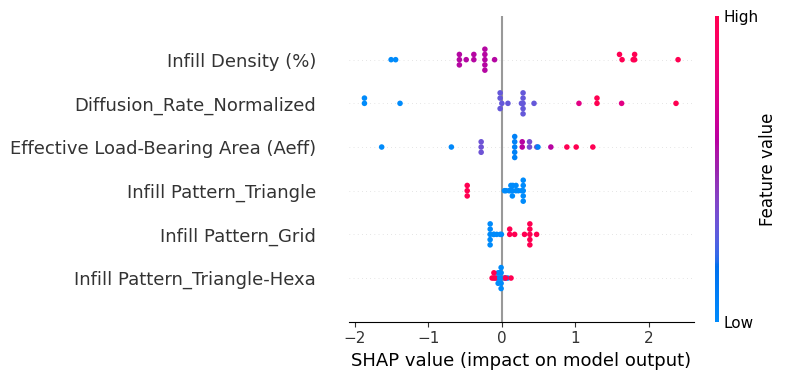

In [24]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer
explainer = shap.TreeExplainer(cat_physics)

# 2. Calculate SHAP values for your test set
# Use the actual physics features dataframe
shap_values = explainer.shap_values(X_test)

# 3. Plot the Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES_PHYSICS)